Using device: cuda
Total training/validation images: 60000
Total testing images: 10000
Training images for model: 50000
Validation images for model: 10000

--- Starting VAE Training ---


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1: Train Loss: -515.8055, Val Loss: -88.2560
Epoch 2: Train Loss: 182.6451, Val Loss: 376.1813
Epoch 3: Train Loss: 477.7114, Val Loss: 537.4166
Epoch 4: Train Loss: 592.3156, Val Loss: 630.0758
Epoch 5: Train Loss: 662.3841, Val Loss: 717.3146
Epoch 6: Train Loss: 719.2884, Val Loss: 736.6416
Epoch 7: Train Loss: 769.8493, Val Loss: 769.0888
Epoch 8: Train Loss: 808.1097, Val Loss: 851.3737
Epoch 9: Train Loss: 847.3739, Val Loss: 882.8270
Epoch 10: Train Loss: 877.1795, Val Loss: 856.5120
Epoch 11: Train Loss: 907.0565, Val Loss: 857.5047
Epoch 12: Train Loss: 926.4761, Val Loss: 969.5710
Epoch 13: Train Loss: 947.4336, Val Loss: 966.7856
Epoch 14: Train Loss: 964.7126, Val Loss: 992.0828
Epoch 15: Train Loss: 987.3191, Val Loss: 1012.8587
Epoch 16: Train Loss: 997.3451, Val Loss: 1035.7588
Epoch 17: Train Loss: 1018.2014, Val Loss: 1050.0489
Epoch 18: Train Loss: 1025.9624, Val Loss: 1011.9287
Epoch 19: Train Loss: 1041.5791, Val Loss: 1078.5081
Epoch 20: Train Loss: 1046.6063

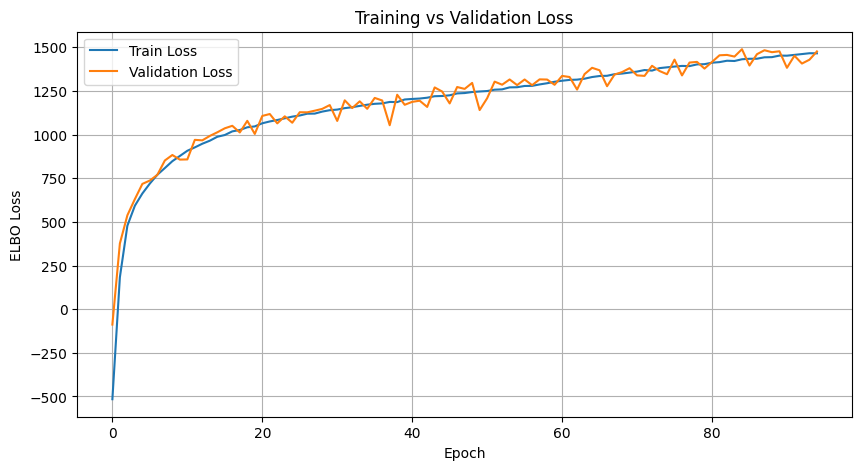

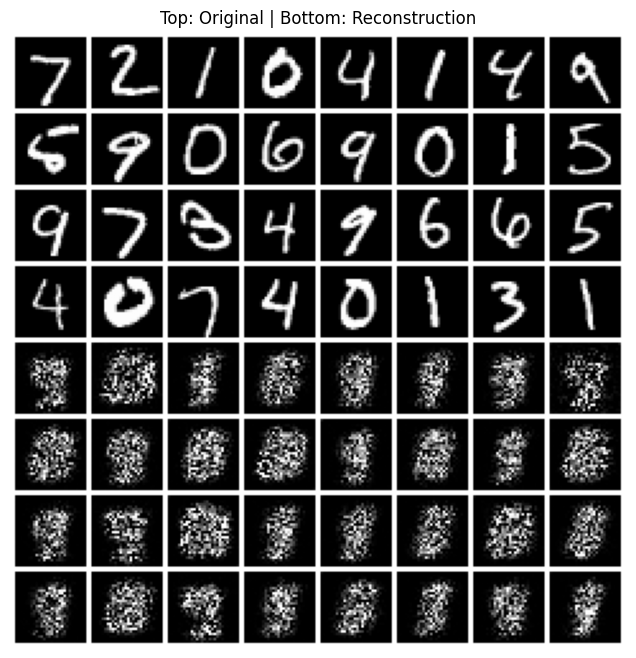

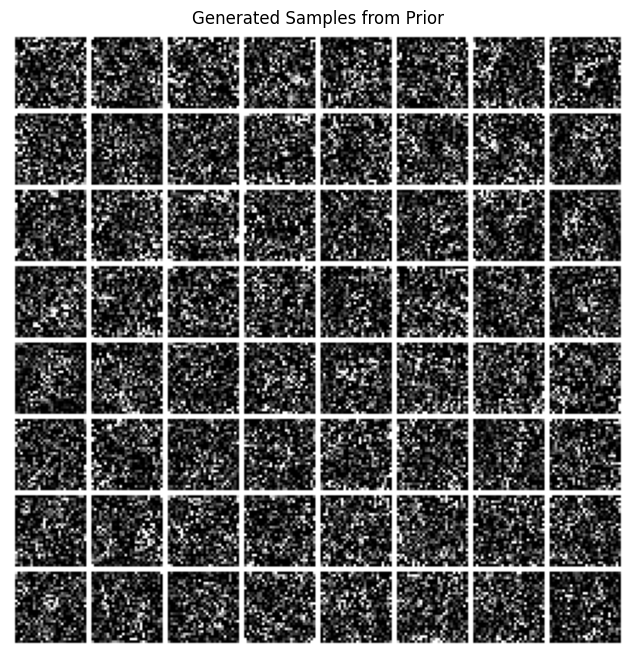

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt

# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- VAE Model Definition ---
class Encoder(nn.Module):
    def __init__(self, img_channels, latent_dim):
        super(Encoder, self).__init__()
        # Input: 1x28x28 (MNIST)
        # We'll design a "cleaner" architecture that maps 28x28 -> 14x14 -> 7x7
        self.conv1 = nn.Conv2d(img_channels, 32, kernel_size=4, stride=2, padding=1) # -> 32x14x14
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1) # -> 64x7x7
        self.bn2 = nn.BatchNorm2d(64)

        # The flattened size will be 64 channels * 7 * 7
        self.flattened_size = 64 * 7 * 7

        # Fully connected layers to output latent variable parameters
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.view(-1, self.flattened_size) # Flatten the feature map
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, img_channels, latent_dim):
        super(Decoder, self).__init__()
        self.initial_channels = 64
        self.initial_dim = 7

        # A fully connected layer to project the latent vector back into a feature map
        self.fc = nn.Linear(latent_dim, self.initial_channels * self.initial_dim * self.initial_dim)

        # Transposed convolutions to upsample the image back to 28x28
        # We match the encoder's architecture: 7x7 -> 14x14 -> 28x28
        self.deconv1 = nn.ConvTranspose2d(self.initial_channels, 32, kernel_size=4, stride=2, padding=1) # -> 32x14x14
        self.bn1_dec = nn.BatchNorm2d(32)

        # The final two layers will output the parameters (mean and log-variance) of the pixel-wise Gaussian distributions.
        self.deconv2_mu = nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1) # -> 1x28x28
        self.deconv2_logvar = nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1) # -> 1x28x28

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.initial_channels, self.initial_dim, self.initial_dim) # Reshape to (batch, 64, 7, 7)
        x = F.relu(self.bn1_dec(self.deconv1(x)))
        mu_x = self.deconv2_mu(x)
        logvar_x = self.deconv2_logvar(x)
        return mu_x, logvar_x



class VAE(nn.Module):
    def __init__(self, img_channels, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(img_channels, latent_dim)
        self.decoder = Decoder(img_channels, latent_dim)

    #reparametrization trick - for bakcpropagation
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_reconst_mu, x_reconst_logvar = self.decoder(z)
        return x_reconst_mu, x_reconst_logvar, mu, logvar

# --- ELBO Loss Function ---
def vae_loss(x, x_reconst_mu, x_reconst_logvar, mu, logvar, D):
    sigma_sq = torch.exp(x_reconst_logvar)

    recon_loss_per_component = 0.5 * torch.log(2 * torch.pi * sigma_sq + 1e-8) + 0.5 * ((x - x_reconst_mu)**2) / (sigma_sq + 1e-8)
    recon_loss = torch.sum(recon_loss_per_component, dim=[1,2,3])

    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

    total_loss = torch.mean(recon_loss + kl_divergence)
    return total_loss, torch.mean(recon_loss), torch.mean(kl_divergence)

# --- Data Loading and Preprocessing ---
def load_mnist_data(batch_size):
    transform = transforms.Compose([
        transforms.ToTensor(), # Converts PIL Image to FloatTensor and scales pixels to [0, 1]
    ])

    train_val_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    print(f"Total training/validation images: {len(train_val_dataset)}")
    print(f"Total testing images: {len(test_dataset)}")

    # Split training data into training (50k) and validation (10k)
    train_size = 50000
    val_size = len(train_val_dataset) - train_size
    train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"Training images for model: {len(train_dataset)}")
    print(f"Validation images for model: {len(val_dataset)}")

    return train_loader, val_loader, test_loader

# --- Training Routine ---
def train_vae(model, train_loader, val_loader, optimizer, epochs, K, D, patience=10):
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        total_recon_loss = 0
        total_kl_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            x_reconst_mu, x_reconst_logvar, mu, logvar = model(data)
            loss, recon_loss, kl_loss = vae_loss(data, x_reconst_mu, x_reconst_logvar, mu, logvar, D)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_recon_loss = total_recon_loss / len(train_loader)
        avg_kl_loss = total_kl_loss / len(train_loader)

        # Validation step
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(device)
                x_reconst_mu, x_reconst_logvar, mu, logvar = model(data)
                loss, _, _ = vae_loss(data, x_reconst_mu, x_reconst_logvar, mu, logvar, D)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(-avg_train_loss)
        val_losses.append(-avg_val_loss)

        print(f"Epoch {epoch+1}: Train Loss: {-avg_train_loss:.4f}, Val Loss: {-avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {patience} epochs with no improvement.")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("ELBO Loss")
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.grid(True)
    plt.show()

import torchvision.utils as vutils

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        recon_x = mu_x + std_x * torch.randn_like(std_x)  # sample x' ~ N(mu, sigma²)

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        gen_x = mu_x + std_x * torch.randn_like(std_x)

    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    IMG_CHANNELS = 1 # MNIST is grayscale
    IMG_WIDTH = 28
    IMG_HEIGHT = 28
    D = IMG_CHANNELS * IMG_WIDTH * IMG_HEIGHT # Total number of features in the data
    LATENT_DIM = 20 # K, must be > 1 as per requirement. Let's choose 20.

    BATCH_SIZE = 128
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 200 # You might want to increase this for better results

    train_loader, val_loader, test_loader = load_mnist_data(BATCH_SIZE)

    vae_model = VAE(IMG_CHANNELS, LATENT_DIM).to(device)
    optimizer = optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)

    print(f"\n--- Starting VAE Training ---")
    train_vae(vae_model, train_loader, val_loader, optimizer, NUM_EPOCHS, LATENT_DIM, D)

    test_vae_reconstruction_and_generation(vae_model, test_loader, device=device)
    generate_from_prior(vae_model, num_samples=64, device=device)


